<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_4_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Juan Diego Muñeton - Robert Alexander Blandon

# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

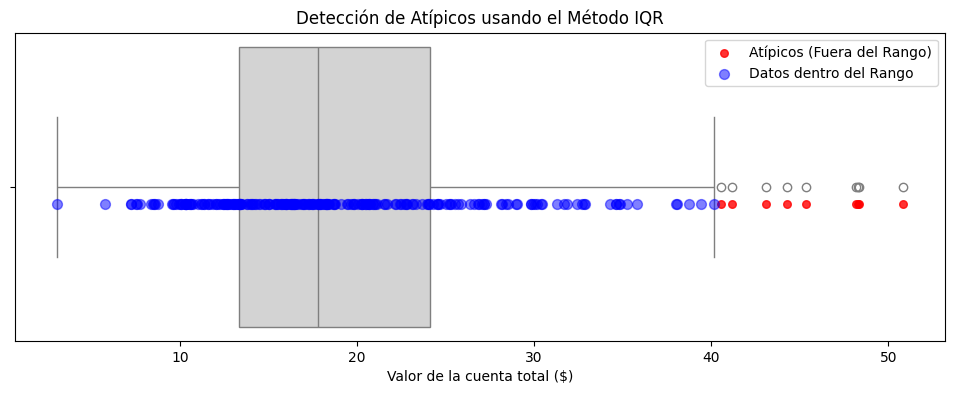

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values

Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]

plt.figure(figsize=(12,4))
sns.boxplot(x=total_bill, color="lightgray")
plt.scatter(data_a, [0.05]*len(data_a), color="red", s=30, alpha=0.8, label="Atípicos (Fuera del Rango)")
plt.scatter(data_b, [0.05]*len(data_b), color="blue", s=50, zorder=5, alpha=0.5, label="Datos dentro del Rango")

plt.xlabel("Valor de la cuenta total ($)")
plt.title("Detección de Atípicos usando el Método IQR")
plt.legend()
plt.show()

# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

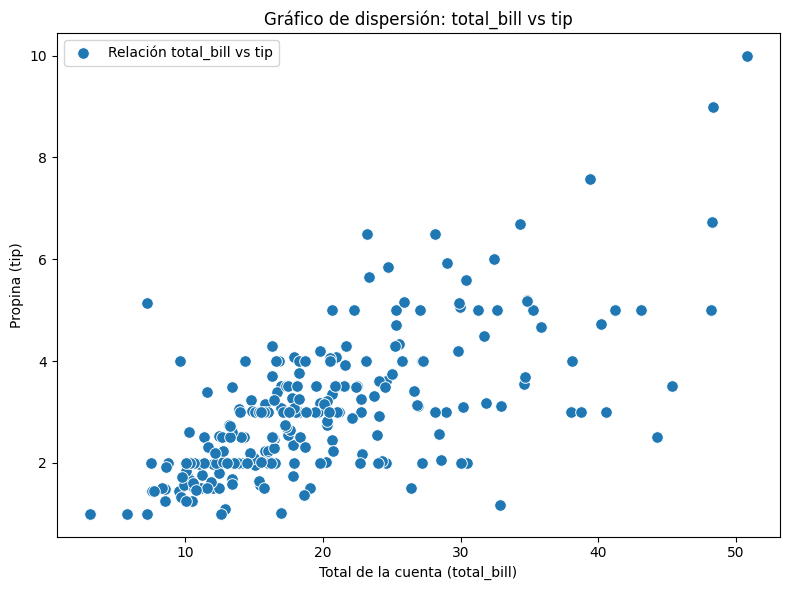

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

tips = sns.load_dataset("tips")

x = tips["total_bill"].values
y = tips["tip"].values

plt.figure(figsize=(8,6))

# Scatter
sns.scatterplot(x=x, y=y, s=70, label="Relación total_bill vs tip")

# Etiquetas de ejes
plt.xlabel("Total de la cuenta (total_bill)")
plt.ylabel("Propina (tip)")

# Título
plt.title("Gráfico de dispersión: total_bill vs tip")

# Leyenda
plt.legend()

plt.tight_layout()
plt.show()

# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

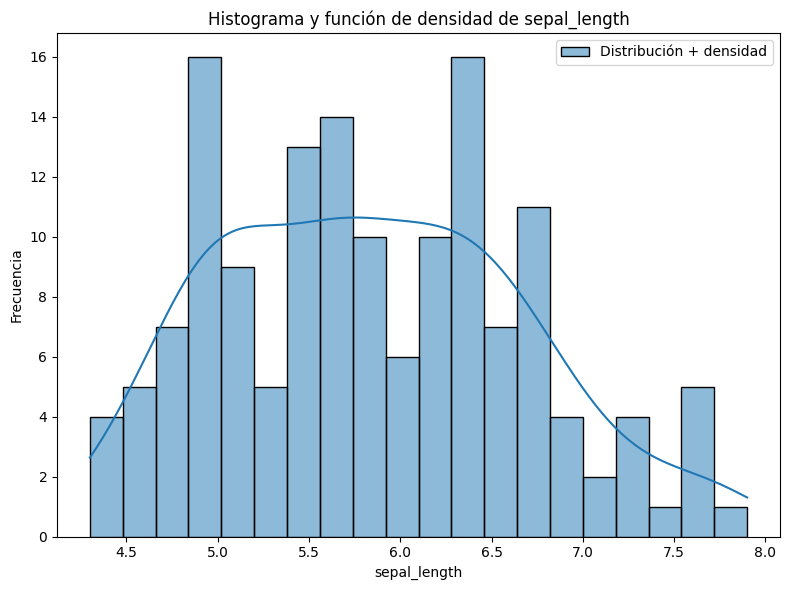

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

iris = sns.load_dataset("iris")
x = iris["sepal_length"].values

plt.figure(figsize=(8,6))

sns.histplot(x, bins=20, kde=True, label="Distribución + densidad")

plt.xlabel("sepal_length")
plt.ylabel("Frecuencia")

plt.title("Histograma y función de densidad de sepal_length")

plt.legend()

plt.tight_layout()
plt.show()

# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

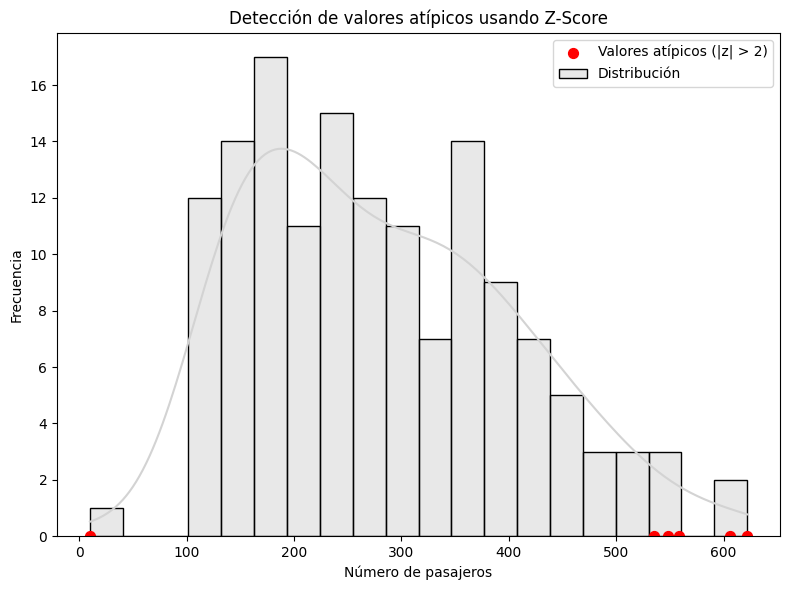

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

flights = sns.load_dataset("flights")
x = flights["passengers"].values

x = np.append(x, [10, 500])

z_scores = zscore(x)
data_b = np.abs(z_scores) > 2

plt.figure(figsize=(8,6))

sns.histplot(x=x, bins=20, kde=True, color="lightgray", label="Distribución")

plt.scatter(x[data_b], np.zeros_like(x[data_b]),
            color="red", s=50, marker="o", label="Valores atípicos (|z| > 2)")

plt.xlabel("Número de pasajeros")
plt.ylabel("Frecuencia")

plt.title("Detección de valores atípicos usando Z-Score")

plt.legend()

plt.tight_layout()
plt.show()

# <span style="color:#2F749F;"><strong>Ejercicio 5: K-means</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

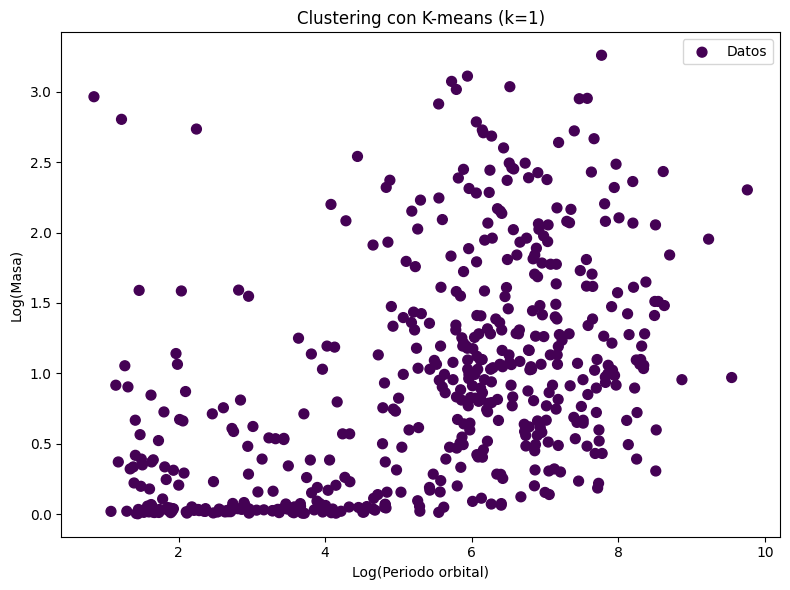

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

planets = sns.load_dataset("planets").dropna(subset=["orbital_period", "mass"])
X = planets[["orbital_period", "mass"]].values
X = np.log1p(X)

kmeans = KMeans(n_clusters=1, random_state=42).fit(X)
labels = kmeans.labels_

plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", s=50, label="Datos")

plt.xlabel("Log(Periodo orbital)")
plt.ylabel("Log(Masa)")

plt.title("Clustering con K-means (k=1)")

plt.legend()

plt.tight_layout()
plt.show()